In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = 'PRSA_Data_Aotizhongxin_20130301-20170228.csv'
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [8]:
print("--- Missing Values Count ---")
print(df[['PM2.5', 'PM10', 'TEMP', 'CO']].isnull().sum())

# Statistical summary to identify potential outliers (e.g., extreme CO or TEMP)
print("\n--- Sensor Statistics ---")
display(df[['PM2.5', 'TEMP', 'CO']].describe())

--- Missing Values Count ---
PM2.5     925
PM10      718
TEMP       20
CO       1776
dtype: int64

--- Sensor Statistics ---


,PM2.5,TEMP,CO
count,34139.000000,35044.000000,33288.000000
mean,82.773611,13.584607,1262.945145
std,82.135694,11.399097,1221.436236
min,3.000000,-16.800000,100.000000
25%,22.000000,3.100000,500.000000
50%,58.000000,14.500000,900.000000
75%,114.000000,23.300000,1500.000000
max,898.000000,40.500000,10000.000000


In [9]:
# Task: Handle missing values using pandas interpolation
# We apply this to numerical sensor columns to maintain the timeline
sensor_columns = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN']

for col in sensor_columns:
    df[col] = df[col].interpolate(method='linear')

print("Missing values after interpolation:")
print(df[['PM2.5', 'PM10', 'TEMP', 'CO']].isnull().sum())

Missing values after interpolation:
PM2.5    0
PM10     0
TEMP     0
CO       0
dtype: int64


In [10]:
# Task: Handle outliers using the IQR method
# Calculate bounds for PM2.5
Q1 = df['PM2.5'].quantile(0.25)
Q3 = df['PM2.5'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print(f"PM2.5 Lower Bound: {lower_limit}")
print(f"PM2.5 Upper Bound: {upper_limit}")

# Create a cleaned version by capping values to the bounds (Winsorization)
df['PM2.5_cleaned'] = df['PM2.5'].clip(lower=lower_limit, upper=upper_limit)

print("\nOutlier handling complete: Extremes capped to the mathematical bounds.")

PM2.5 Lower Bound: -116.0
PM2.5 Upper Bound: 252.0

Outlier handling complete: Extremes capped to the mathematical bounds.


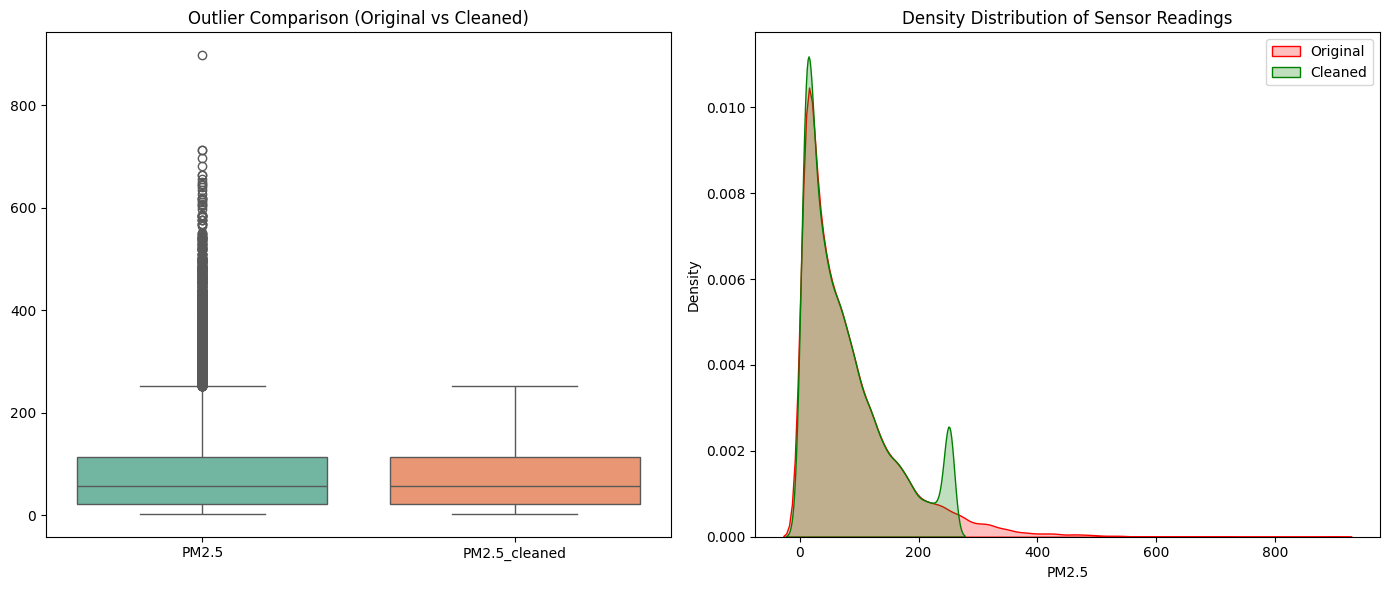

In [11]:
# Visualize the cleaning results
plt.figure(figsize=(14, 6))

# Boxplot Comparison
plt.subplot(1, 2, 1)
sns.boxplot(data=df[['PM2.5', 'PM2.5_cleaned']], palette="Set2")
plt.title('Outlier Comparison (Original vs Cleaned)')

# Distribution Comparison
plt.subplot(1, 2, 2)
sns.kdeplot(df['PM2.5'], label='Original', fill=True, color="red")
sns.kdeplot(df['PM2.5_cleaned'], label='Cleaned', fill=True, color="green")
plt.title('Density Distribution of Sensor Readings')
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
# Export the cleaned dataframe to CSV
df.to_csv('cleaned_beijing_sensors.csv', index=False)
print("Final Task 16 result saved as 'cleaned_beijing_sensors.csv'")

Final Task 16 result saved as 'cleaned_beijing_sensors.csv'
